# Lab 5 — Bases, determinants, and the shortest vector, from scratch

**Maths for Post-Quantum Cryptography**, Chapter 5: *Lattices*

---

Four pieces. Part A implements Gram-Schmidt orthogonalisation, the
computational tool behind the chapter's determinant identity. Part B makes
Derivation 5.1's abstract "same lattice, different basis" claim concrete by
generating one numerically and comparing it with a genuinely bad basis for
the identical point set. Part C checks Minkowski's proven bound and the
Gaussian heuristic's unproven prediction against brute-force truth, across
enough dimensions to see the heuristic's accuracy actually improve. Part D
builds a $q$-ary lattice and confirms its determinant is exactly $q^m$.

**Part A — a lattice from a basis.** Gram-Schmidt orthogonalisation
(Section 5.3) for an arbitrary integer basis; confirm
$|\det B| = \prod_i \|b_i^*\|$ on 200 random bases in dimensions 2-6.

**Part B — unimodular equivalence.** Random unimodular $U$ (products of
elementary shears, Derivation 5.1), applied to a basis; confirm the
transformed basis generates the identical point set inside a bounded box,
while its Gram-Schmidt vectors can be dramatically longer.

**Part C — successive minima vs. the two bounds.** Brute-force the shortest
vector of random small lattices, confirm Minkowski's bound (Section 5.4) is
never violated, and compare $\lambda_1$ against the Gaussian heuristic
(Section 5.5) as dimension increases.

**Part D — a $q$-ary lattice.** Build $\Lambda_q^\perp(A)$ for random $A$,
confirm $\det = q^m$ by exhaustive counting (Derivation 5.5), and reproduce
the book's toy example exactly.

### Requirements

```
python >= 3.9
numpy
matplotlib
```

Nothing else — every algorithm here is written directly from the chapter's
derivations, in plain Python, with no lattice-reduction library standing in
for the mathematics (that is Chapter 8's job).

### How to use this notebook

Run it top to bottom once. Worked solutions for the pencil-and-paper
exercises (5.1-5.9) are in Appendix C of the book.

Every section ends with `assert` statements, and the final cell is a single
`_selftest()` that repeats all of them. CI runs this notebook on every
commit; if an assertion fires on your machine, that is a bug in the lab, not
in your understanding — please open an issue.

In [1]:
from __future__ import annotations

import itertools
import random
from math import gamma, pi, e, sqrt

import numpy as np
import matplotlib.pyplot as plt

# Same print-safe, black-and-white styling as Labs 1-4.
plt.rcParams.update({
    "figure.figsize": (7.5, 3.4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "axes.prop_cycle": plt.cycler(color=["0.15", "0.45", "0.65"]),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 9,
})

random.seed(0)
np.random.seed(0)
print(f"numpy {np.__version__}")

numpy 2.4.4


---

## Part A — a lattice from a basis

Gram-Schmidt orthogonalisation, Section 5.3: `gram_schmidt(B)` returns the
orthogonal (not orthonormal, and generally not lattice vectors) frame
$b_1^*,\ldots,b_n^*$, and the determinant identity
$|\det B| = \prod_i \|b_i^*\|$ is checked against the direct determinant on
200 random integer bases, dimensions 2 through 6.

In [2]:
def gram_schmidt(B):
    """B: (n,n) array, rows are basis vectors. Returns (Bstar, mu)."""
    n = B.shape[0]
    Bstar = np.zeros_like(B, dtype=float)
    mu = np.eye(n)
    for i in range(n):
        Bstar[i] = B[i].astype(float)
        for j in range(i):
            mu[i, j] = np.dot(B[i], Bstar[j]) / np.dot(Bstar[j], Bstar[j])
            Bstar[i] -= mu[i, j] * Bstar[j]
    return Bstar, mu


def random_basis(n, low=-6, high=6, max_tries=200):
    for _ in range(max_tries):
        B = np.random.randint(low, high + 1, size=(n, n))
        if abs(round(np.linalg.det(B))) > 0:
            return B
    raise RuntimeError("could not find a full-rank basis")


# The book's running example: b1=(4,2), b2=(1,3).
B_book = np.array([[4, 2], [1, 3]])
Bstar_book, mu_book = gram_schmidt(B_book)
print("b1* =", Bstar_book[0], " b2* =", Bstar_book[1], " mu_21 =", mu_book[1, 0])
assert np.allclose(Bstar_book[0], [4, 2])
assert np.allclose(Bstar_book[1], [-1, 2])
assert abs(mu_book[1, 0] - 0.5) < 1e-9

det_direct = abs(round(np.linalg.det(B_book)))
det_gso = np.prod(np.linalg.norm(Bstar_book, axis=1))
print(f"det via |det B| = {det_direct}, det via prod||b_i*|| = {det_gso:.6f}")
assert abs(det_direct - det_gso) < 1e-6

# Now 200 random bases, dimensions 2-6.
checked = 0
for _ in range(200):
    n = random.choice([2, 3, 4, 5, 6])
    B = random_basis(n)
    Bstar, _ = gram_schmidt(B)
    det_direct = abs(round(np.linalg.det(B)))
    det_gso = np.prod(np.linalg.norm(Bstar, axis=1))
    assert abs(det_direct - det_gso) < 1e-6 * max(1, det_direct)
    checked += 1
print(f"|det B| == prod||b_i*|| confirmed on {checked} random bases, dims 2-6")

b1* = [4. 2.]  b2* = [-1.  2.]  mu_21 = 0.5
det via |det B| = 10, det via prod||b_i*|| = 10.000000
|det B| == prod||b_i*|| confirmed on 200 random bases, dims 2-6


---

## Part B — unimodular equivalence

A random unimodular matrix, built as a product of elementary shears
(Derivation 5.1), applied to a basis. Two checks: the transformed basis
generates the *identical* point set inside a bounded box, and its
Gram-Schmidt vectors are typically far longer — reproducing Figure 5.2's
good-vs-bad contrast as numbers instead of a picture.

In [3]:
def random_unimodular(n, steps=8, k_range=(-2, 2)):
    U = np.eye(n, dtype=int)
    for _ in range(steps):
        i, j = random.sample(range(n), 2)
        k = 0
        while k == 0:
            k = random.randint(*k_range)
        shear = np.eye(n, dtype=int)
        shear[i, j] = k
        U = U @ shear
    return U


def lattice_points_in_box(B, radius, coeff_range=16):
    """All lattice points within `radius` of the origin, found by
    brute-forcing integer coefficients up to coeff_range. A skewed (bad)
    basis needs a much larger coeff_range than a good one to reach the same
    points near the origin -- large, near-cancelling coefficients are
    exactly what makes a basis bad -- so this default is generous and
    both calls below use the same value rather than tuning it per basis."""
    n = B.shape[0]
    pts = set()
    for coeffs in itertools.product(range(-coeff_range, coeff_range + 1), repeat=n):
        v = np.array(coeffs) @ B
        if np.linalg.norm(v) <= radius:
            pts.add(tuple(v.tolist()))
    return pts


# Reproduce the book's good/bad pair exactly.
B_good = np.array([[4, 2], [1, 3]])
U = np.array([[1, 3], [0, 1]])
B_bad = U @ B_good
print("B_good =\n", B_good)
print("B_bad = U @ B_good =\n", B_bad, " det(U) =", round(np.linalg.det(U)))
assert round(np.linalg.det(U)) in (1, -1)

pts_good = lattice_points_in_box(B_good, radius=12)
pts_bad = lattice_points_in_box(B_bad, radius=12)
print(f"points within radius 12: good basis {len(pts_good)}, bad basis {len(pts_bad)}")
assert pts_good == pts_bad

Bstar_good, _ = gram_schmidt(B_good)
Bstar_bad, _ = gram_schmidt(B_bad)
print("good GSO norms:", np.linalg.norm(Bstar_good, axis=1))
print("bad  GSO norms:", np.linalg.norm(Bstar_bad, axis=1))
assert abs(np.prod(np.linalg.norm(Bstar_good, axis=1)) - np.prod(np.linalg.norm(Bstar_bad, axis=1))) < 1e-6

# General experiment: random unimodular transforms, dimension 10, worst/best
# Gram-Schmidt vector length ratio.
ratios = []
for _ in range(100):
    n = 10
    B = random_basis(n, low=-3, high=3)
    U = random_unimodular(n, steps=12)
    Bt = U @ B
    Ut_inv = np.linalg.inv(U)
    assert np.allclose(np.round(Ut_inv), Ut_inv)  # U^{-1} is integer too
    Bstar_t, _ = gram_schmidt(Bt)
    norms = np.linalg.norm(Bstar_t, axis=1)
    ratios.append(norms.max() / norms.min())
ratios = np.array(ratios)
print(f"n=10, 100 random unimodular transforms: "
      f"worst/best GSO-vector ratio mean={ratios.mean():.1f}, max={ratios.max():.1f}")
assert ratios.mean() > 1.0

B_good =
 [[4 2]
 [1 3]]
B_bad = U @ B_good =
 [[ 7 11]
 [ 1  3]]  det(U) = 1
points within radius 12: good basis 45, bad basis 45
good GSO norms: [4.47213595 2.23606798]
bad  GSO norms: [13.03840481  0.76696499]
n=10, 100 random unimodular transforms: worst/best GSO-vector ratio mean=227.2, max=5250.6


---

## Part C — successive minima vs. the two bounds

Brute-force shortest-vector search on random small lattices, checked against
Minkowski's proven bound (never violated, by the theorem) and the Gaussian
heuristic's prediction (an estimate, not a bound — and one that should get
*more* accurate, not less, as dimension grows).

Minkowski bound, n=2, det=10: 3.5682482323055424
Gaussian heuristic, n=2, det=10: 1.0821259771793594


Minkowski bound checked on 60 random lattices (n=2,3,4): 0 violations
n=2: mean lambda_1/GH = 2.649  (over 15 lattices)
n=3: mean lambda_1/GH = 2.057  (over 15 lattices)
n=4: mean lambda_1/GH = 1.751  (over 15 lattices)


n=5: mean lambda_1/GH = 1.413  (over 15 lattices)


n=6: mean lambda_1/GH = 1.525  (over 15 lattices)


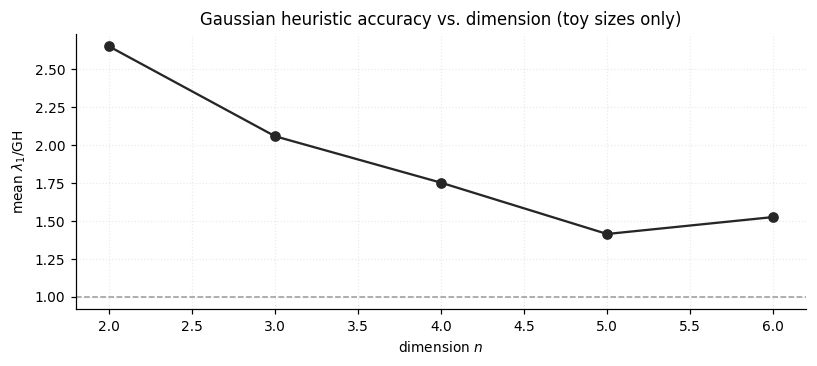

In [4]:
def shortest_vector_bruteforce(B, coeff_range=6):
    n = B.shape[0]
    best = None
    for coeffs in itertools.product(range(-coeff_range, coeff_range + 1), repeat=n):
        if all(c == 0 for c in coeffs):
            continue
        v = np.array(coeffs) @ B
        norm = np.linalg.norm(v)
        if best is None or norm < best:
            best = norm
    return best


def ball_volume(n):
    return pi ** (n / 2) / gamma(n / 2 + 1)


def minkowski_bound(n, detL):
    return 2 * (detL / ball_volume(n)) ** (1 / n)


def gaussian_heuristic(n, detL):
    return sqrt(n / (2 * pi * e)) * detL ** (1 / n)


# The book's worked example.
detL = 10.0
print("Minkowski bound, n=2, det=10:", minkowski_bound(2, detL))
print("Gaussian heuristic, n=2, det=10:", gaussian_heuristic(2, detL))
assert abs(minkowski_bound(2, detL) - 2 * sqrt(detL / pi)) < 1e-9

# Minkowski's bound, checked against brute force, dimensions 2-4 (brute force
# gets expensive fast -- Chapter 8 exists precisely because this does not scale).
violations = 0
trials_run = 0
for n in (2, 3, 4):
    for _ in range(20):
        B = random_basis(n, low=-5, high=5)
        detL = abs(round(np.linalg.det(B)))
        lam1 = shortest_vector_bruteforce(B, coeff_range=4)
        bound = minkowski_bound(n, detL)
        trials_run += 1
        if lam1 > bound + 1e-9:
            violations += 1
print(f"Minkowski bound checked on {trials_run} random lattices (n=2,3,4): "
      f"{violations} violations")
assert violations == 0

# Gaussian heuristic accuracy vs. dimension: ratio lambda_1 / GH, averaged,
# should drift towards 1 as n grows (never proven here -- just observed).
mean_ratios = {}
for n in (2, 3, 4, 5, 6):
    ratios = []
    for _ in range(15):
        B = random_basis(n, low=-3, high=3)
        detL = abs(round(np.linalg.det(B)))
        if detL == 0:
            continue
        lam1 = shortest_vector_bruteforce(B, coeff_range=3)
        gh = gaussian_heuristic(n, detL)
        ratios.append(lam1 / gh)
    mean_ratios[n] = float(np.mean(ratios))
    print(f"n={n}: mean lambda_1/GH = {mean_ratios[n]:.3f}  (over {len(ratios)} lattices)")

fig, ax = plt.subplots()
ax.plot(list(mean_ratios.keys()), list(mean_ratios.values()), marker="o", color="0.15")
ax.axhline(1.0, color="0.6", linestyle="--", linewidth=1)
ax.set_xlabel("dimension $n$")
ax.set_ylabel(r"mean $\lambda_1 / \mathrm{GH}$")
ax.set_title("Gaussian heuristic accuracy vs. dimension (toy sizes only)")
plt.tight_layout()
plt.show()

---

## Part D — a $q$-ary lattice

$\Lambda_q^\perp(A) = \{x \in \mathbb{Z}^n : Ax \equiv 0 \pmod q\}$, built for
random $A$, with its determinant confirmed to be exactly $q^m$ by exhaustive
counting (Derivation 5.5) — then the book's toy example, $q=5$, $A=(2,1)$,
reproduced exactly.

In [5]:
def qary_index_and_solutions(A, q):
    """Brute-force count of x in {0,...,q-1}^n with A x = 0 (mod q), and the
    resulting index [Z^n : Lambda_q^perp(A)] = q^n / (solution count)."""
    m, n = A.shape
    count = 0
    for x in itertools.product(range(q), repeat=n):
        xv = np.array(x)
        if all((A[i] @ xv) % q == 0 for i in range(m)):
            count += 1
    index = q ** n // count
    return count, index


def modular_rank(A, q):
    """Rank of A over Z_q, by Gaussian elimination mod q."""
    M = [row[:] for row in A.tolist()]
    rows, cols = len(M), len(M[0])
    rank, row = 0, 0
    for col in range(cols):
        piv = next((r for r in range(row, rows) if M[r][col] % q != 0), None)
        if piv is None:
            continue
        M[row], M[piv] = M[piv], M[row]
        inv = pow(int(M[row][col]), -1, q)
        M[row] = [(x * inv) % q for x in M[row]]
        for r in range(rows):
            if r != row and M[r][col] % q != 0:
                factor = M[r][col]
                M[r] = [(M[r][c] - factor * M[row][c]) % q for c in range(cols)]
        row += 1
        rank += 1
        if row == rows:
            break
    return rank


# The book's toy example: q=5, A=(2,1).
q, A = 5, np.array([[2, 1]])
count, index = qary_index_and_solutions(A, q)
print(f"q=5, A=(2,1): solutions mod q = {count}, index (det) = {index}")
assert index == q ** 1

# check the two orthogonal basis vectors from Figure 5.5 span exactly this lattice
basis = np.array([[2, 1], [-1, 2]])
assert (basis[0] @ A[0]) % q == 0 and (basis[1] @ A[0]) % q == 0
assert abs(round(np.linalg.det(basis))) == index

# General check: random full-row-rank A, several (q, m, n) triples.
for q, n, m, trials in [(5, 3, 1, 4), (3, 4, 2, 4), (7, 5, 2, 3)]:
    checked = 0
    while checked < trials:
        A = np.random.randint(0, q, size=(m, n))
        if modular_rank(A, q) != m:
            continue
        count, index = qary_index_and_solutions(A, q)
        assert count == q ** (n - m)
        assert index == q ** m
        checked += 1
    print(f"q={q}, n={n}, m={m}: det(Lambda_q^perp(A)) == q^m confirmed on {trials} random full-rank A")

q=5, A=(2,1): solutions mod q = 5, index (det) = 5
q=5, n=3, m=1: det(Lambda_q^perp(A)) == q^m confirmed on 4 random full-rank A
q=3, n=4, m=2: det(Lambda_q^perp(A)) == q^m confirmed on 4 random full-rank A
q=7, n=5, m=2: det(Lambda_q^perp(A)) == q^m confirmed on 3 random full-rank A


---

## What to take away

Every quantity this lab computed is basis-independent except one: the
Gram-Schmidt vectors themselves, which depend on both the basis *and* the
order its vectors are listed in. That is not a loose end — it is exactly
the fact Chapter 8 is built on. A lattice's determinant, its successive
minima, its membership in the $q$-ary family: none of that changes no
matter which basis you write down. But *how good* a particular basis is at
revealing $\lambda_1$ changes enormously, as Part B's ratio experiment
showed directly. Lattice reduction — LLL, then BKZ — is the algorithm that
searches for a better basis without changing the lattice underneath it, and
Chapter 8 measures exactly how much work that search costs.

In [6]:
# --------------------------------------------------------------------------
# CI smoke test. Runs on every commit; keeps this notebook honest against
# library updates. If this cell fails, the lab is broken -- please open an issue.
# --------------------------------------------------------------------------
def _selftest():
    B = np.array([[4, 2], [1, 3]])
    Bstar, mu = gram_schmidt(B)
    assert np.allclose(Bstar[0], [4, 2]) and np.allclose(Bstar[1], [-1, 2])
    assert abs(np.prod(np.linalg.norm(Bstar, axis=1)) - 10.0) < 1e-6

    for _ in range(20):
        n = random.choice([2, 3, 4])
        Bt = random_basis(n)
        Bst, _ = gram_schmidt(Bt)
        assert abs(abs(round(np.linalg.det(Bt))) - np.prod(np.linalg.norm(Bst, axis=1))) < 1e-6

    U = np.array([[1, 3], [0, 1]])
    B_bad = U @ B
    assert lattice_points_in_box(B, radius=10) == lattice_points_in_box(B_bad, radius=10)

    assert abs(minkowski_bound(2, 10.0) - 2 * sqrt(10.0 / pi)) < 1e-9
    lam1 = shortest_vector_bruteforce(B, coeff_range=4)
    assert lam1 <= minkowski_bound(2, 10.0) + 1e-9
    assert abs(lam1 - sqrt(10.0)) < 1e-6

    q, A = 5, np.array([[2, 1]])
    count, index = qary_index_and_solutions(A, q)
    assert count == 5 and index == 5

    return "all checks passed"

print(_selftest())

all checks passed
